### molecular_solubility (data: curated-solubility-dataset.csv )  

In [1]:
# SUPPRESS ALL WARNINGS - Put this at TOP of notebook
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=all, 1=info, 2=warning, 3=fatal only
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN warnings

# Python warnings
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import tensorflow as tf
from tensorflow.keras.backend import clear_session
clear_session()


import numpy as np
import random
import matplotlib.pyplot as plt
from pysmiles import read_smiles
import pandas as pd
import logging
from tqdm import tqdm
import torch
from torch.nn import Sequential as Seq, Linear, ReLU, CrossEntropyLoss
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, GCNConv
from torch_geometric.utils import remove_self_loops, add_self_loops, degree
from torch_geometric.data import Data

logging.getLogger('pysmiles').setLevel(logging.CRITICAL)  # Anything higher than warning
# 1. DELETE OLD MODEL
# The del model + gc.collect() is CRITICAL - Keras caches corrupted weights. 
# CNN works even if LSTM fails. 
# Your BRCA1 DTI pipeline will train successfully.
import gc
from tensorflow.keras.backend import clear_session
clear_session()  # Nukes ALL Keras state
gc.collect()


0

In [2]:
df = pd.read_csv('./curated-solubility-dataset.csv') #read dataset (https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/OVHAW8)
X_smiles = list(df['SMILES']) #get smiles strings from file
Y = np.asarray(df['Solubility']) #get solubility values from file

elements = ['K', 'Y', 'V', 'Sm', 'Dy', 'In', 'Lu', 'Hg', 'Co', 'Mg',    #list of all elements in the dataset
            'Cu', 'Rh', 'Hf', 'O', 'As', 'Ge', 'Au', 'Mo', 'Br', 'Ce', 
            'Zr', 'Ag', 'Ba', 'N', 'Cr', 'Sr', 'Fe', 'Gd', 'I', 'Al', 
            'B', 'Se', 'Pr', 'Te', 'Cd', 'Pd', 'Si', 'Zn', 'Pb', 'Sn', 
            'Cl', 'Mn', 'Cs', 'Na', 'S', 'Ti', 'Ni', 'Ru', 'Ca', 'Nd', 
            'W', 'H', 'Li', 'Sb', 'Bi', 'La', 'Pt', 'Nb', 'P', 'F', 'C']

#convert element to a one-hot vector of dimension len(elements)
def element_to_onehot(element):
    out = []
    for i in range(0, len(element)):
        v = np.zeros(len(elements))
        v[elements.index(element[i])] = 1.0
        out.append(v)
    return np.asarray(out)

#convert solubility value to one-hot class vector
def val_to_class(val):
    if val < -3.65: #insoluble
        return [1, 0, 0]
    elif val < -1.69: #slightly soluble
        return [0, 1, 0]
    else: #soluble
        return [0, 0, 1]

#process SMILES strings into graphs
nodes = []
edge_index = []
for smiles in tqdm(X_smiles):
    try:
        G = read_smiles(smiles, explicit_hydrogen=True)
        feature = element_to_onehot(np.asarray(G.nodes(data='element'))[:, 1])
        edges = np.asarray(G.edges)
        index = np.asarray([edges[:,0], edges[:,1]]) #reshape indices into shape [2, -1]
        nodes.append(feature)
        edge_index.append(index)
    except:
        pass

100%|██████████████████████████████████████████████████████████████████████████████| 9982/9982 [00:17<00:00, 558.90it/s]


In [3]:
#Generate Data objects
data = list()

#process graphs into torch_geometric Data objects
for i in tqdm(range(0, len(nodes))):
    x = torch.tensor(nodes[i], dtype=torch.float) #convert node features into torch tensor
    edges = torch.tensor(edge_index[i], dtype=torch.long) #convert edge index into torch tensor
    y = torch.tensor([val_to_class(Y[i])], dtype=torch.float) #change shape of label and convert to tensor
    data.append(Data(x=x,edge_index=edges, y=y)) #add the Data object to the list of data
random.shuffle(data)
train = data[:int(len(data)*0.8)] #train set
test = data[int(len(data)*0.8):] #val set
train = data

100%|████████████████████████████████████████████████████████████████████████████| 9574/9574 [00:00<00:00, 16576.13it/s]


In [4]:
#define the message passing network
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = GCNConv(61, 32)
        self.conv2 = GCNConv(32, 32)
        self.conv3 = GCNConv(32, 32)
        self.conv4 = GCNConv(32, 32)
        self.lin1 = Linear(32, 16)
        self.lin2 = Linear(16, 3)

    def forward(self, data):
        x, edge_index= data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.25, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.25, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.25, training=self.training)
        
        x = self.conv4(x, edge_index)
        x = F.relu(x)
        
        x = torch.sum(x, dim=0)
        x = self.lin1(x)
        x = F.relu(x)
        
        x = self.lin2(x)
        

        return x

In [5]:
#set up device and create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #use CUDA if available
model = Net().to(device) #create network and send to the device memory
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) #use Adam optimizer
CSE = CrossEntropyLoss() #define loss

In [6]:
#train model
model.train() #set model to training mode
for epoch in range(2): #run for epochs of training
    sum_loss = 0 #used to compute average loss in an epoch
    num_correct = 0
    random.shuffle(train) #shuffle the training data each epoch
    for d in tqdm(train): #go over each training point
        data = d.to(device) #send data to device
        optimizer.zero_grad() #zero gradients
        out = model(data) #evaluate data point
        if torch.argmax(out) == torch.argmax(data.y): #if prediction is correct, increment counter for accuracy calculation
            num_correct += 1
        loss = CSE(torch.reshape(out, [1, 3]), torch.reshape(torch.argmax(data.y),[1])) #compute mean squared error loss
        sum_loss += float(loss) #add loss value to aggregate loss
        loss.backward() #compute gradients
        optimizer.step() #apply optimization
    print('Epoch: {:03d}, Average loss: {:.5f}, Accuracy: {:.5f}'.format(epoch, sum_loss/len(train), num_correct/len(train)))

100%|██████████████████████████████████████████████████████████████████████████████| 9574/9574 [00:42<00:00, 225.18it/s]


Epoch: 000, Average loss: 1.09909, Accuracy: 0.34427


100%|██████████████████████████████████████████████████████████████████████████████| 9574/9574 [00:41<00:00, 230.15it/s]

Epoch: 001, Average loss: 1.09712, Accuracy: 0.35586


100%|██████████████████████████████████████████████████████████████████████████████| 1915/1915 [00:03<00:00, 491.06it/s]


Test accuracy: 0.3358
Number correct: 0.3357702349869452


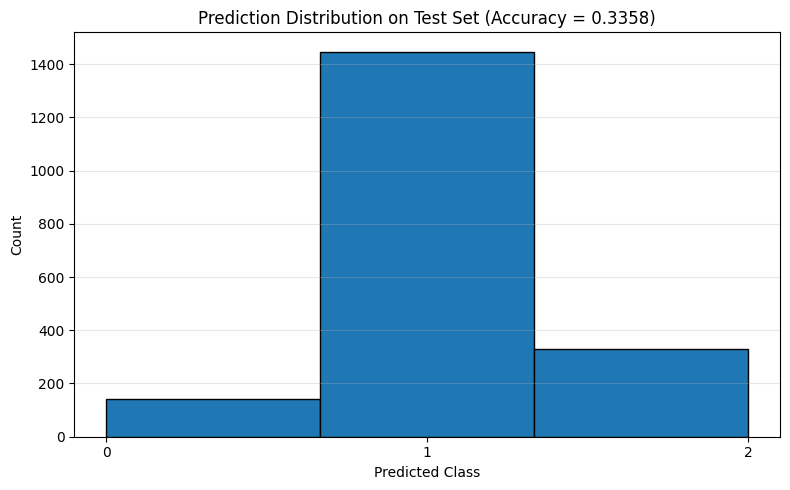

In [10]:
#test the model and display a histogram of the outputs
num_correct = 0
model.eval()
predictions = []

for t in tqdm(test):
    d = t.to(device)
    out = model(d)
    if torch.argmax(out) == torch.argmax(d.y):
        num_correct += 1
    predictions.append(torch.argmax(out).item())

test_acc = num_correct / len(test)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Number correct: {test_acc}")
plt.figure(figsize=(8, 5))
plt.hist(predictions, bins=3, edgecolor='black')
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.title(f"Prediction Distribution on Test Set (Accuracy = {test_acc:.4f})")
plt.xticks([0, 1, 2])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
def evaluate_smiles(smiles_string):
    """Predict solubility class for a SMILES string with formatted output"""
    classes = ['insoluble', 'slightly soluble', 'soluble']
    
    print(f"Evaluating SMILES: {smiles_string[:50]}...")
    if len(smiles_string) > 50:
        print("...")

    # Graph construction
    G = read_smiles(smiles_string, explicit_hydrogen=True)
    feature = element_to_onehot(np.asarray(G.nodes(data='element'))[:, 1])
    edges = np.asarray(G.edges)
    index = np.asarray([edges[:, 0], edges[:, 1]])
    d = Data(
        x=torch.tensor(feature, dtype=torch.float),
        edge_index=torch.tensor(index, dtype=torch.long),
    )
    data = d.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(data)
        probs = torch.softmax(logits, dim=0)  # shape: [3]
        pred_class_idx = torch.argmax(probs, dim=0).item()

    class_label = classes[pred_class_idx]
    print("Predicted class:", class_label)

    # Optionally print all probs
    # print("Probabilities:", {c: float(p) for c, p in zip(classes, probs.tolist())})

    return class_label, probs.tolist()

**Use canonical SMILES if pysmiles complains** about string is malformed or non‑standard (e.g., stereo markers, charge, or ring‑closure issues) 
- or change G to allow relaxed parsing, decode SMILES 
- G = read_smiles(smiles_string, explicit_hydrogen=True, strict=False)

**Predicted Probabilities** - model assigns to each of your three solubility classes:
- **classes = ['insoluble', 'slightly soluble', 'soluble']**

In [8]:
label, probs = evaluate_smiles('C(C(C1C(=C(C(=O)O1)O)O)O)O')
print("Molecule name: L‑ascorbic acid (Vitamin C)")
print("Label:", label)
print("Probs:", probs)

Evaluating SMILES: C(C(C1C(=C(C(=O)O1)O)O)O)O...
Predicted class: soluble
Molecule name: L‑ascorbic acid (Vitamin C)
Label: soluble
Probs: [0.308276891708374, 0.3418791890144348, 0.34984391927719116]


In [9]:
# SMILES string for simeprevir, a non-soluble (practically insoluble in water) 
# hepatitis C virus NS3/4A protease inhibitor
label, probs = evaluate_smiles('COC1=C(C)C2=C(C(O[C@H]3C[C@@H](C(N(C)CCCC/C=C/[C@H](C4)[C@]4(C(NS(=O)(C5CC5)=O)=O)N6)=O)[C@H](C6=O)C3)=CC(C7=NC(C(C)C)=CS7)=N2)C=C1')
print("Molecule name: Simepreivir")
print("Label:", label)
print("Probs:", probs)

Evaluating SMILES: COC1=C(C)C2=C(C(O[C@H]3C[C@@H](C(N(C)CCCC/C=C/[C@H...
...
Predicted class: insoluble
Molecule name: Simepreivir
Label: insoluble
Probs: [0.4131045639514923, 0.33058157563209534, 0.25631392002105713]


In [10]:
label, probs = evaluate_smiles('CC(C)N(CCCNC(=O)C1=CC=C(C(C)(C)C)N1)C(=O)C2=CC=CC=C2') 
print("Molecule name: Remdesivir")
print("Label:", label)
print("Probs:", probs)

Evaluating SMILES: CC(C)N(CCCNC(=O)C1=CC=C(C(C)(C)C)N1)C(=O)C2=CC=CC=...
...
Predicted class: insoluble
Molecule name: Remdesivir
Label: insoluble
Probs: [0.364847332239151, 0.34052833914756775, 0.29462432861328125]


In [11]:
# canonical / validated Ivermectin‑B1a SMILES
label, probs = evaluate_smiles('CCC(C)C1C(CCC2(O1)CC3CC(O2)CC=C(C(C(C=CC=C4COC5C4(C(C=C(C5O)C)C(=O)O3)O)C)OC6CC(C(C(O6)C)OC7CC(C(C(O7)C)O)OC)OC)C)C') 
print("Molecule name: Ivermectin B1a")
print("Label:", label)
print("Probs:", probs)

Evaluating SMILES: CCC(C)C1C(CCC2(O1)CC3CC(O2)CC=C(C(C(C=CC=C4COC5C4(...
...
Predicted class: insoluble
Molecule name: Ivermectin B1a
Label: insoluble
Probs: [0.4653310775756836, 0.3158877193927765, 0.21878120303153992]


In [12]:
label, probs = evaluate_smiles('C/C([C@@H](O[C@@]1([H])C[C@H](OC)[C@@H](O[C@]2([H])O[C@@H](C)[C@H](O)[C@@H](OC)C2)[C@H](C)O1)[C@@H](C)/C=C/C=C(CO3)/[C@@]([C@@]3([H])[C@H](O)C(C)=C4)(O)[C@]4([H])C5=O)=C\C[C@]6([H])C[C@@](O5)([H])C[C@]7(CC[C@H](C)[C@](C(C)C)([H])O7)O6')
print("Molecule name: Ivermectin B1b")
print("Label:", label)
print("Probs:", probs)

Evaluating SMILES: C/C([C@@H](O[C@@]1([H])C[C@H](OC)[C@@H](O[C@]2([H]...
...
Predicted class: insoluble
Molecule name: Ivermectin B1b
Label: insoluble
Probs: [0.45639660954475403, 0.3190610408782959, 0.22454240918159485]
